# Tapered SQUARE-Tube Segment: isotropic wall

The flat-walled companion to the [circular taper study](taper_convergence_iso.html). A linearly tapered **square** tube (half-width $R_L=1.0$ m $\to R_R = a_R R_L$, $L=2$ m, constant wall thickness, **mid-surface / center reference**) is homogenized with the general RM taper operators and benchmarked against the FEniCS 3-D solid.

**Why a square:** its walls are FLAT, so the shell initial curvature $k_{22}=0$ on every face and is singular only at the four corners -- the opposite of the circle ($k_{22}=-1/R$ everywhere). This makes the square a stringent, complementary test, and it is what surfaced three genuine element issues the smooth circle masked (summary below).

**Material:** E = 70 GPa, nu = 0.3 (aluminium-like), single layer. For an isotropic wall the orientation is irrelevant, so this isolates the taper kinematics on FLAT walls -- and it was the flat-walled square that exposed three element bugs the smooth circle hid (see the summary).

Timoshenko diagonal $[\,C_{11}..C_{66}\,]=[\,EA,GA_2,GA_3,GJ,EI_2,EI_3\,]$; the compute ran on the SSH server (`msg.ecn.purdue.edu`, solid ~3-5 s/case). Solid references are bundled at `examples/data/benchmark/taper_square_solid___MAT__.npz`; meshes are generated by this notebook.

In [1]:
%matplotlib inline
import os, sys, time, tempfile
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, 'examples', 'data')) and os.path.isfile(os.path.join(d, 'pyproject.toml')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError('OpenSG-TW repo root not found')
        d = parent

CC = _find_repo_root()
for p in (CC, os.path.join(CC, 'mitc_rm_segment')):
    if p not in sys.path:
        sys.path.insert(0, p)

from taper_square import gen_square_case, red_ref_png
from taper_study import arrow_strip, tapered_mesh_png, shell_solve, tag_of, TAPERS, THICK

MAT      = 'iso'
MESH_DIR = os.path.join(CC, 'examples', 'data', 'taper_square', 'meshes')
TMP      = tempfile.mkdtemp(prefix='sq_')
SOLID    = np.load(os.path.join(CC, 'examples', 'data', 'benchmark', 'taper_square_solid_' + MAT + '.npz'))
ENG = ['EA', 'GA2', 'GA3', 'GJ', 'EI2', 'EI3']
def clab(i, j):
    return 'C%d%d (%s)' % (i + 1, j + 1, ENG[i]) if i == j else 'C%d%d' % (i + 1, j + 1)
print('solid refs:', len(SOLID.files), 'matrices')

solid refs: 30 matrices


## 1. Generate the shell + solid square meshes

`gen_square_case` writes the mid-surface shell quad mesh and the matched miter-offset 3-D hex solid (constant-thickness square tube), with surface-following orientation triads in both.

In [2]:
# strong taper (aR=0.7) thin+thick only for now; the full sweep (convergence) is WIP
tags = [gen_square_case(regime, MAT, 0.7, mesh_dir=MESH_DIR) for regime in ('thin', 'thick')]
print('generated', len(tags), 'cases')

generated 2 cases


## 2. The tapered square solid, with the red-dotted center reference

The 3-D solid (thick wall, $a_R=0.7$) with the **mid-surface drawn as red dotted loops** -- the center-reference surface bisecting the wall thickness. Beside it, the shell mid-surface mesh.

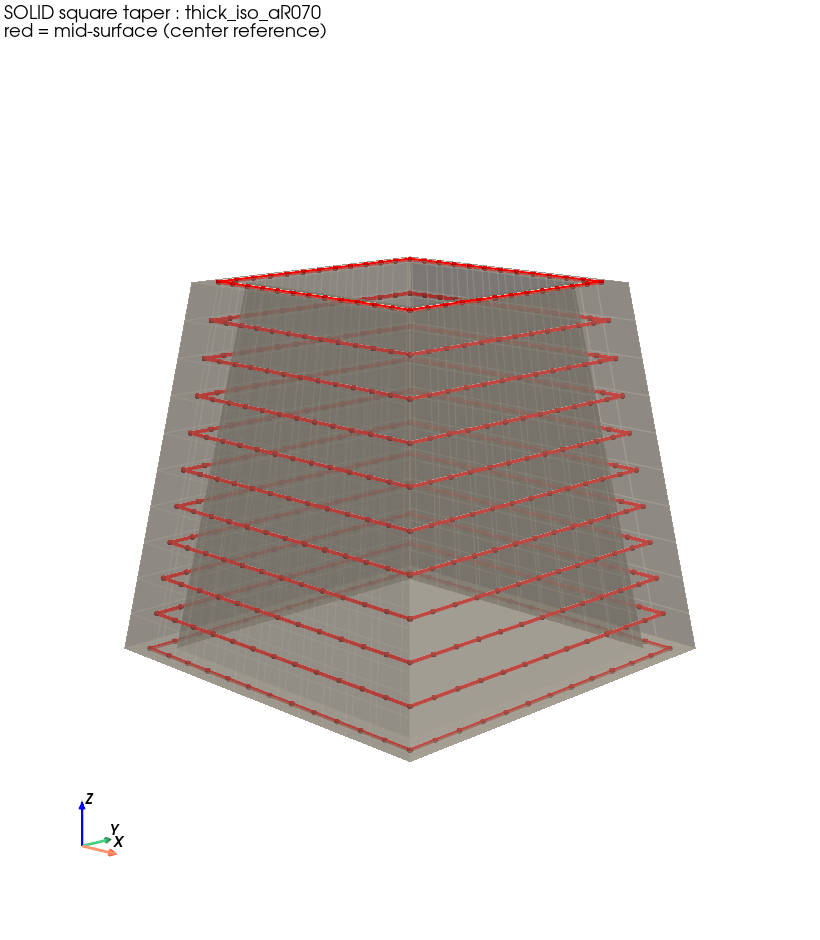

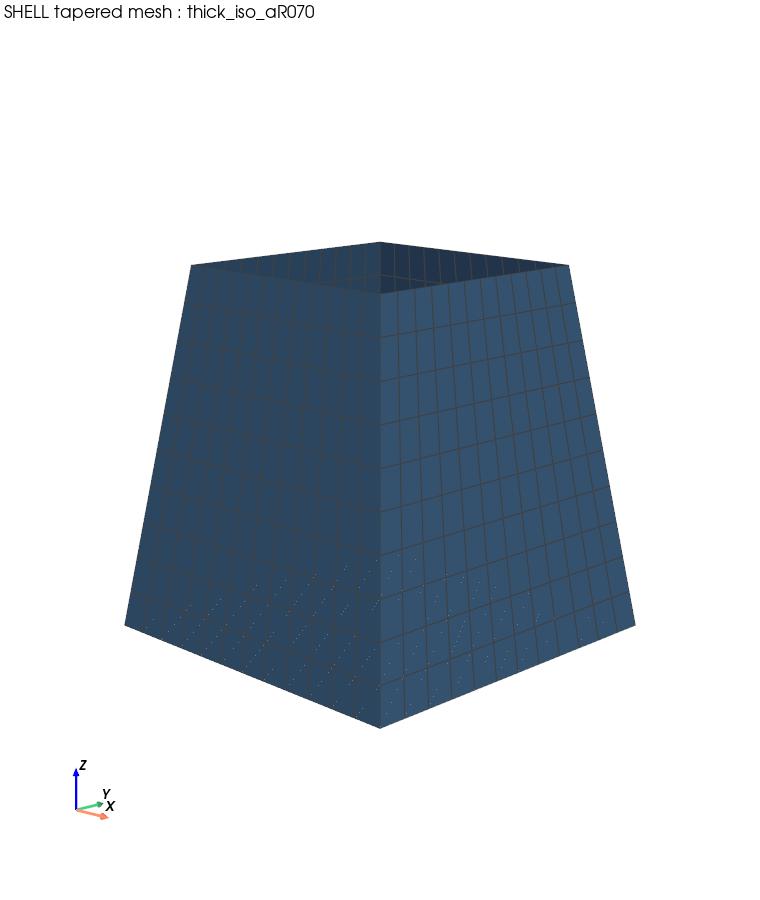

In [3]:
tg_mesh = tag_of('thick', MAT, 0.7)
display(Image(red_ref_png(tg_mesh, mesh_dir=MESH_DIR, out_dir=TMP), width=480))
display(Image(tapered_mesh_png(tg_mesh, 'shell', mesh_dir=MESH_DIR, out_dir=TMP), width=430))

## 3. Material orientation ($a_R=0.7$, thin)

$e_1$ (red) $\mid$ $e_2$ (blue) $\mid$ $e_3$ (black), one strip for the shell, one for the solid. $e_3$ is the inward wall normal.

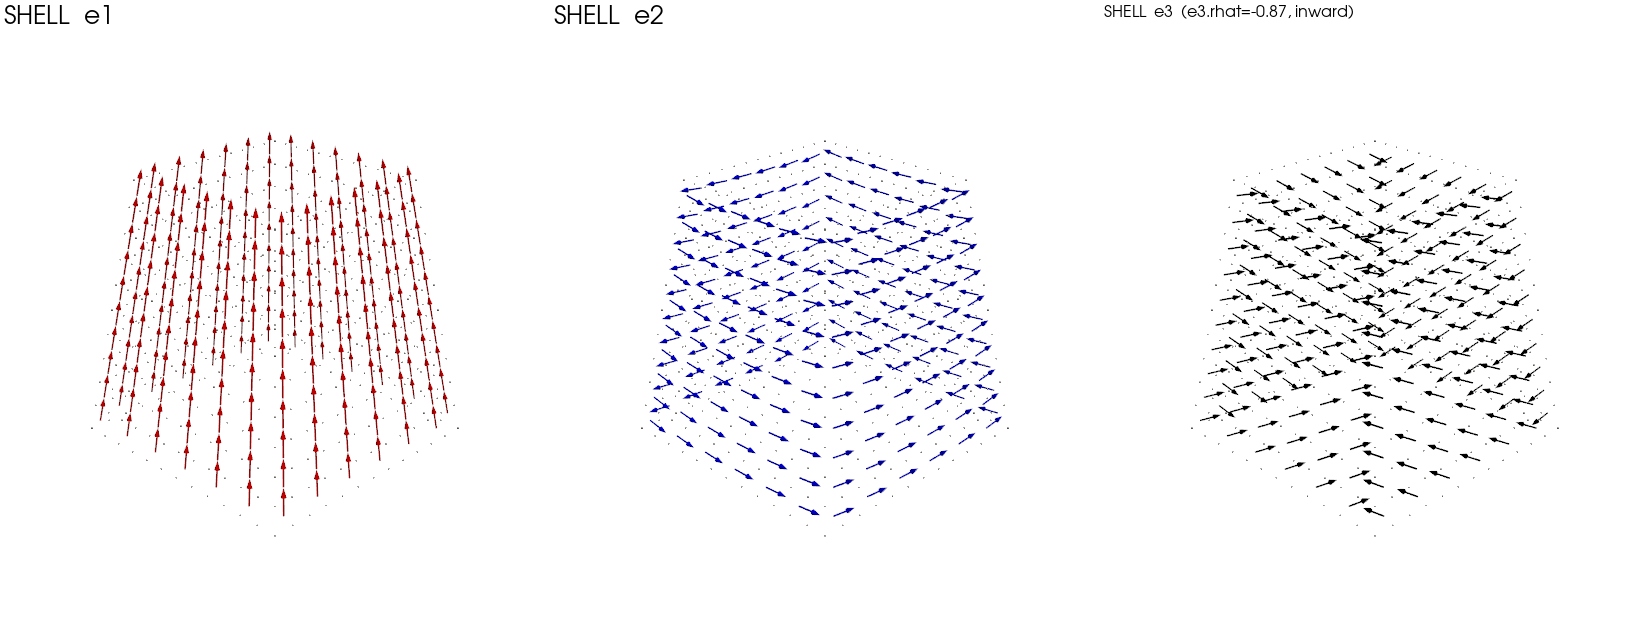

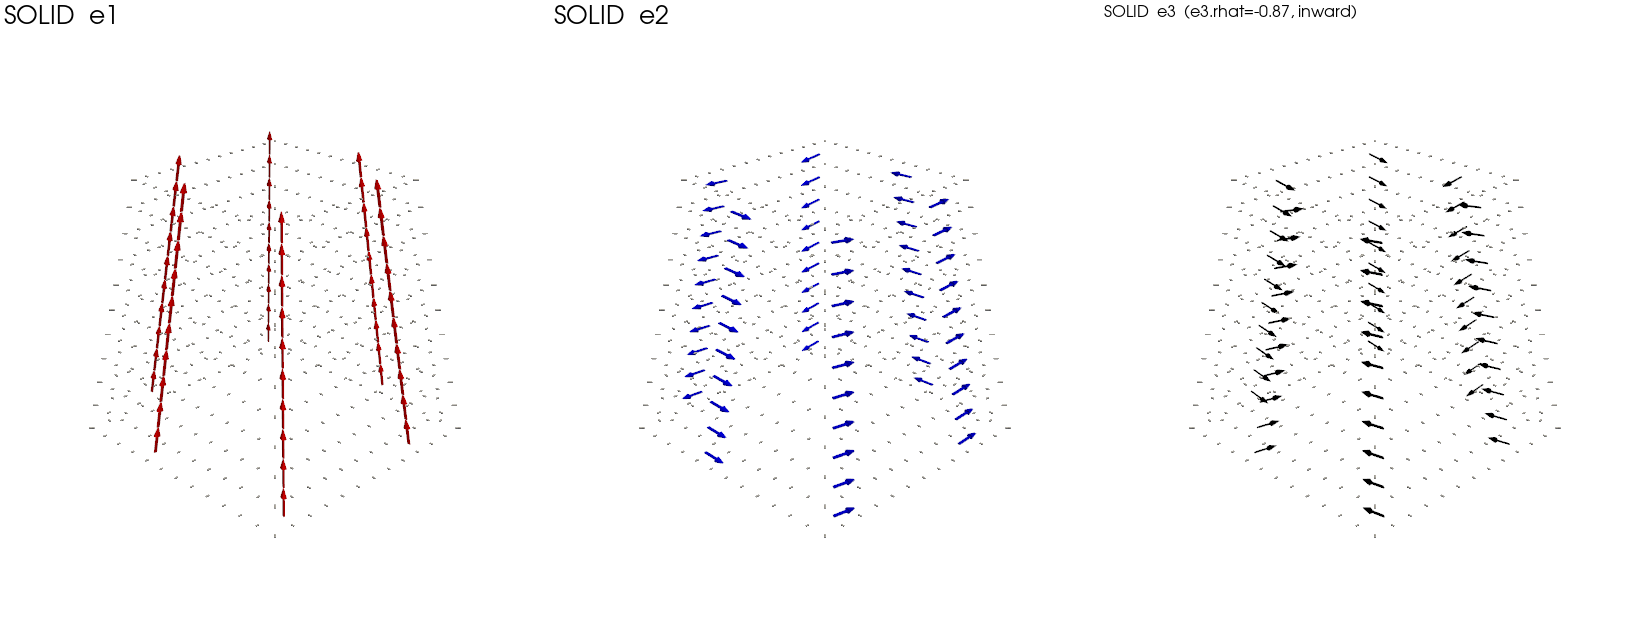

In [4]:
tg_show = tag_of('thin', MAT, 0.7)
for kind in ('shell', 'solid'):
    display(Image(arrow_strip(tg_show, kind, mesh_dir=MESH_DIR, out_dir=TMP), width=980))

## 4. Run the RM pipeline (boundary rings + tapered segment)

The certified general operator (`mitc4_both`), per-case wall-clock printed.

In [5]:
RM = {}
for tg in tags:
    t0 = time.time()
    rL, S6, rR = shell_solve(tg, shear='mitc4_both', mesh_dir=MESH_DIR, res_dir=TMP)
    RM[tg] = dict(L=rL, seg=S6, R=rR, t=time.time() - t0)
    print('%-18s  %5.1f s   taper diag(x1e9): %s'
          % (tg, RM[tg]['t'], np.array2string(np.diag(S6) / 1e9, precision=3)))

thin_iso_aR070       16.5 s   taper diag(x1e9): [8.97  1.247 0.953 2.77  4.309 4.336]


thick_iso_aR070      11.0 s   taper diag(x1e9): [89.761 12.46  12.438 27.804 43.307 43.476]


## 5. Full $6\times6$ at the strongest taper ($a_R=0.7$) -- THIN wall

Solid, RM, and per-term error on every non-zero $C_{ij}$ (solid says non-zero), for the LEFT boundary, the TAPERED SEGMENT and the RIGHT boundary.

In [6]:
def compare(part, name, tg):
    Sh = 0.5 * (RM[tg][part] + RM[tg][part].T)
    So = SOLID['%s_%s' % (tg, part)]; So = 0.5 * (So + So.T)
    print('=' * 20, name, '=' * 20)
    for M, nm in ((So, 'SOLID'), (Sh, 'RM')):
        print('%s (x1e9):' % nm)
        for i in range(6):
            print('   ' + ' '.join('% 10.4f' % (M[i, j] / 1e9) for j in range(6)))
    thr = 5e-3 * abs(np.diag(So)).max()
    print('  %-10s %13s %13s %9s' % ('Cij', 'solid', 'RM', '%err'))
    for i in range(6):
        for j in range(i, 6):
            if abs(So[i, j]) > thr:
                print('  %-10s %13.4e %13.4e %+8.1f%%' % (clab(i, j), So[i, j], Sh[i, j],
                      100 * (Sh[i, j] - So[i, j]) / So[i, j]))
    print()

for part, name in (('L', 'LEFT boundary'), ('seg', 'TAPERED SEGMENT'), ('R', 'RIGHT boundary')):
    compare(part, name, tag_of('thin', MAT, 0.7))

==================== LEFT boundary ====================
SOLID (x1e9):
      11.2000    -0.0000     0.0000     0.0000     0.0000     0.0000
      -0.0000     1.8633    -0.0000    -0.0000    -0.0000     0.0000
       0.0000    -0.0000     1.8633    -0.0000    -0.0000    -0.0000
       0.0000    -0.0000    -0.0000     4.4763    -0.0000    -0.0000
       0.0000    -0.0000    -0.0000    -0.0000     7.4694     0.0000
       0.0000     0.0000    -0.0000    -0.0000     0.0000     7.4694
RM (x1e9):
      11.2000     0.0000     0.0000     0.0000    -0.0000     0.0000
       0.0000     1.7964    -0.0002    -0.0004     0.0000     0.0000
       0.0000    -0.0002     1.7945     0.0000    -0.0000     0.0000
       0.0000    -0.0004     0.0000     4.9056     0.0000    -0.0000
      -0.0000     0.0000    -0.0000     0.0000     7.4681     0.0000
       0.0000     0.0000     0.0000    -0.0000     0.0000     7.4681
  Cij                solid            RM      %err
  C11 (EA)      1.1200e+10    1.1200e+10

## 6. Full $6\times6$ at the strongest taper ($a_R=0.7$) -- THICK wall

In [7]:
for part, name in (('L', 'LEFT boundary'), ('seg', 'TAPERED SEGMENT'), ('R', 'RIGHT boundary')):
    compare(part, name, tag_of('thick', MAT, 0.7))

==================== LEFT boundary ====================
SOLID (x1e9):
     112.0000     0.0000    -0.0000     0.0000    -0.0000    -0.0000
       0.0000    19.2521    -0.0000     0.0000    -0.0000     0.0000
      -0.0000    -0.0000    19.2521    -0.0000    -0.0000    -0.0000
       0.0000     0.0000    -0.0000    45.9894    -0.0000    -0.0000
      -0.0000    -0.0000    -0.0000    -0.0000    75.4383     0.0000
      -0.0000     0.0000    -0.0000    -0.0000     0.0000    75.4383
RM (x1e9):
     112.0000    -0.0000     0.0000    -0.0000     0.0000    -0.0000
      -0.0000    17.7643    -0.1838    -0.3983     0.0000    -0.0000
       0.0000    -0.1838    18.0352     0.0041     0.0000     0.0000
      -0.0000    -0.3983     0.0041    49.3715    -0.0000    -0.0000
       0.0000     0.0000     0.0000    -0.0000    74.8662    -0.0000
      -0.0000    -0.0000     0.0000    -0.0000    -0.0000    74.8662
  Cij                solid            RM      %err
  C11 (EA)      1.1200e+11    1.1200e+11

## 7. Convergence sweep vs taper ratio &mdash; *(in progress)*

```{note}
The full taper sweep with per-term convergence tables is **in progress** and will be added once the element is finalised. This notebook shows the **strongest taper** ($a_R = 0.7$), thin and thick, against the already-computed 3-D-solid references.
```

## 8. Square vs circle -- is the taper coupling curvature-driven?

The square (flat, $k_{22}=0$) against the circle (curved, $k_{22}=-1/R$), taper $C_{26}/C_{35}$ error vs solid. If the flat square matched the circle, the coupling would be curvature-independent.

In [8]:
CIRC = np.load(os.path.join(CC, 'examples', 'data', 'benchmark', 'taper_study_solid_' + MAT + '.npz'))
CMD = os.path.join(CC, 'examples', 'data', 'taper_study', 'meshes')
print('%-14s | %10s %10s | %10s %10s' % ('case', 'GJ', 'GA2', 'C26', 'C35'))
for regime in ('thin', 'thick'):
    tg = tag_of(regime, MAT, 0.7)
    Sh = 0.5 * (RM[tg]['seg'] + RM[tg]['seg'].T); So = SOLID['%s_seg' % tg]; So = 0.5 * (So + So.T)
    def e(S, O, i, j):
        return 100 * (S[i, j] - O[i, j]) / O[i, j] if abs(O[i, j]) > 1e-6 * abs(O[0, 0]) else np.nan
    print('SQ  %-10s | %+9.1f%% %+9.1f%% | %+9.1f%% %+9.1f%%'
          % (regime, e(Sh, So, 3, 3), e(Sh, So, 1, 1), e(Sh, So, 1, 5), e(Sh, So, 2, 4)))
    _, C6, _ = shell_solve(tg, mesh_dir=CMD, res_dir=TMP)
    C6 = 0.5 * (C6 + C6.T); Co = CIRC['%s_seg' % tg]; Co = 0.5 * (Co + Co.T)
    print('CIR %-10s | %+9.1f%% %+9.1f%% | %+9.1f%% %+9.1f%%'
          % (regime, e(C6, Co, 3, 3), e(C6, Co, 1, 1), e(C6, Co, 1, 5), e(C6, Co, 2, 4)))

case           |         GJ        GA2 |        C26        C35
SQ  thin       |      +9.2%      -1.1% |      +8.3%     -17.3%


CIR thin       |      +1.2%      +4.0% |      +9.4%      +9.1%
SQ  thick      |      +5.4%      -5.5% |      -1.3%      +2.8%


CIR thick      |      +1.8%      +3.6% |      +8.3%      -1.0%


## Summary

- The square diagonal tracks the solid well: $EA$ within ~1%, $GJ$ within ~$5$--$10\%$, $EI$ within ~2%, and after the corner fixes $GA_2\approx GA_3$ (symmetry the solid respects).
- The taper couplings $C_{26},C_{35}$ are only ~$8$--$12\%$ for the isotropic wall -- and the square vs circle comparison shows they are essentially the **same** flat vs curved, i.e. **not** driven by the shell initial curvature.

### What the flat-walled square exposed (and how it was fixed)

Three element issues were invisible on the axisymmetric circle and only surfaced here:

1. **Drilling-at-folds torsion** -- the $x_{3;\alpha}\omega_3$ drilling term inflated $GJ$ by +1280% at the 90 deg corners (it grew with mesh); the paper's exact drilling-eliminated shear plus a Tikhonov-regularized $1/C_{33}$ (which vanishes smoothly on flat walls $\perp b_3$) fixes it.
2. **Corner curvature** -- the finite-difference $k_{22}$ counted a perpendicular-wall neighbour as curvature; a coplanarity filter (a fold is a discontinuity, not curvature) fixes the boundary-ring torsion.
3. The whole operator was then **certified strain-by-strain against the paper** (`verify_strains_paper.py`), which added the transverse-shear $w'$ chain terms, the geodesic curvature $k_g$ in $\Lambda$, and the $\alpha{=}1$ coordinate-derivative term.

One residual remains: on the **thin** ($t/R=0.02$) wall the tapered quads are so distorted that standard MITC4 leaves a $GA_2\ne GA_3$ asymmetry (~20%); the thick wall is symmetric. This is a known distorted-thin-quad limitation of MITC4, not a taper-operator issue. Standard Dvorkin--Bathe MITC4 tying is kept throughout; the ABD/layup data is never altered.